In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:



np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)


df = df.sample(40)

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [4]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=8,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()
     

In [5]:


# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [6]:
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print('Eigen Values:\n', eigen_values)
print('Eigen Vectors:\n', eigen_vectors)

Eigen Values:
 [1.3536065  0.94557084 0.77774573]
Eigen Vectors:
 [[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


In [8]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [9]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


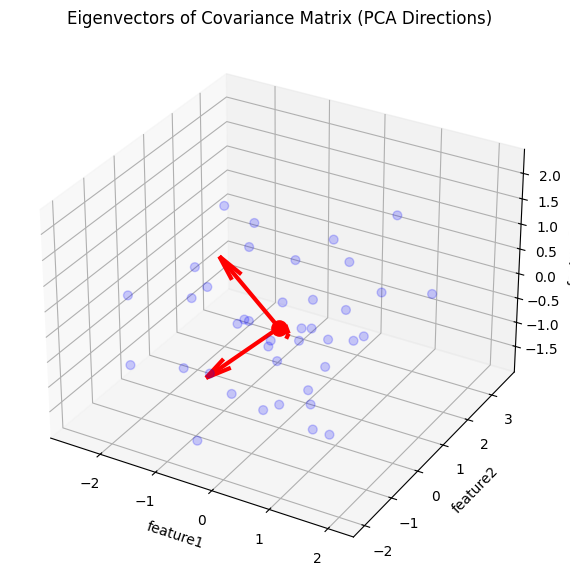

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Mean of the data
mean = df[['feature1', 'feature2', 'feature3']].mean().values

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=40,
    color='blue',
    alpha=0.2
)

# Mean point
ax.scatter(
    mean[0], mean[1], mean[2],
    s=120, color='red'
)

# Plot eigenvectors (PCA directions)
ax.quiver(
    mean[0], mean[1], mean[2],
    eigen_vectors[0, :],
    eigen_vectors[1, :],
    eigen_vectors[2, :],
    length=1.5,
    normalize=True,
    color='red',
    linewidth=3
)

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')
ax.set_title('Eigenvectors of Covariance Matrix (PCA Directions)')

plt.show()


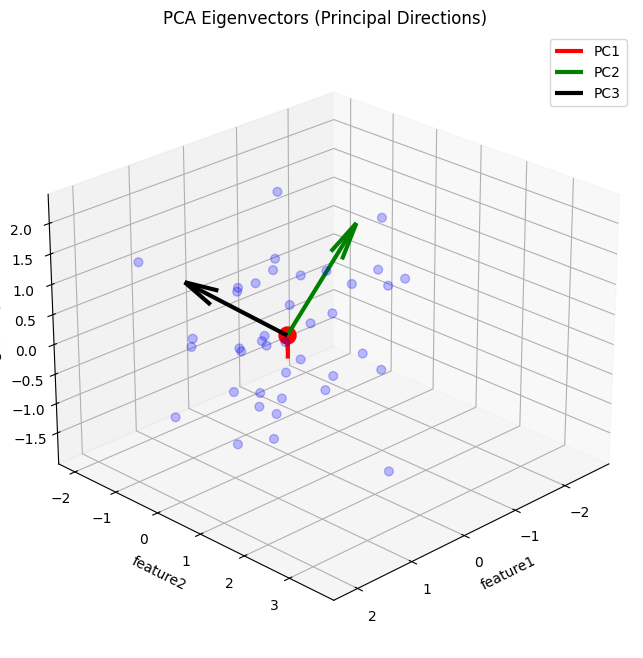

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 1. Prepare data
# -----------------------------
X = df[['feature1', 'feature2', 'feature3']].values

# Mean center
mean = X.mean(axis=0)
X_centered = X - mean

# -----------------------------
# 2. Covariance matrix
# -----------------------------
cov_matrix = np.cov(X_centered, rowvar=False)

# -----------------------------
# 3. Eigen decomposition
# -----------------------------
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues & eigenvectors (important!)
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# -----------------------------
# 4. Plot
# -----------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of data
ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    color='blue',
    alpha=0.25,
    s=40
)

# Mean point
ax.scatter(
    mean[0], mean[1], mean[2],
    color='red',
    s=150
)

# -----------------------------
# 5. Plot eigenvectors correctly
# -----------------------------
colors = ['red', 'green', 'black']
labels = ['PC1', 'PC2', 'PC3']

for i in range(3):
    ax.quiver(
        mean[0], mean[1], mean[2],           # origin
        eigen_vectors[0, i],                 # x direction
        eigen_vectors[1, i],                 # y direction
        eigen_vectors[2, i],                 # z direction
        length=np.sqrt(eigen_values[i]) * 2, # scale by variance
        normalize=True,
        color=colors[i],
        linewidth=3,
        label=labels[i]
    )

# -----------------------------
# 6. Labels & view
# -----------------------------
ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')
ax.set_title('PCA Eigenvectors (Principal Directions)')
ax.legend()

# Nice viewing angle
ax.view_init(elev=25, azim=45)

plt.show()


In [12]:


pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [13]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()
     
     

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [14]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()